# 07_Sistema_Industrial · Pipeline de Monitorización por Capas

**Objetivo**: implementar el sistema de monitorización industrial que integra los tres
datasets del proyecto en una arquitectura de escalada por capas, tal como funcionan
los sistemas reales de mantenimiento predictivo.

---

## Arquitectura del sistema

```
┌─────────────────────────────────────────────────────────────────────┐
│  CAPA 1 — Detección eléctrica          [siempre activa, 1 min]      │
│  Fuente: sensores externos (pinzas amperimétricas)                  │
│  Dataset: SPARK · Señales: P_total, I1/I2/I3, THD, PF              │
│  Modelo: umbral estadístico sobre anomaly_score (Isolation Forest)  │
├─────────────────────────────────────────────────────────────────────┤
│  CAPA 2 — Confirmación mecánica        [se activa si Capa 1 alerta] │
│  Fuente: controlador CNC (OPC-UA / MTConnect) — sin hardware extra  │
│                                                                     │
│  PROTOTIPO  → Dataset KIT (500 Hz, sensores externos): RF + LOO-CV │
│  PRODUCCIÓN → Dataset CNC Mill (señales internas): RF reentrenable │
│                                                                     │
│  El modelo arranca con el baseline KIT y se sustituye en planta por │
│  el modelo CNC, que se reentrena de forma incremental con datos     │
│  reales. Los 18 experimentos CNC actúan como cold-start.           │
├─────────────────────────────────────────────────────────────────────┤
│  CAPA 3 — Clasificación de fallo    [se activa si Capa 2 confirma] │
│  Fuente: MES / SCADA (parámetros de proceso)                        │
│  Dataset: AI4I · Señales: velocidad, torque, desgaste, temperatura  │
│  Modelo: StackingClassifier (LightGBM + RF) — modelo de producción  │
└─────────────────────────────────────────────────────────────────────┘
```

**Principio de diseño industrial**: el sistema es útil aunque solo exista la Capa 1.
Cada capa adicional aumenta la confianza y el detalle del diagnóstico.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle, os, glob, warnings
warnings.filterwarnings('ignore')

import sys; sys.path.insert(0, '../src')
from paths import PROCESSED as PROC_DIR, MODELS as MODELS_DIR

# ── Tipos de fallo AI4I ──────────────────────────────────────────────────────
FAULT_NAMES = {
    0: 'Sin fallo',
    1: 'TWF — Desgaste herramienta',
    2: 'HDF — Fallo disipación calor',
    3: 'PWF — Fallo de potencia',
    4: 'OSF — Sobreesfuerzo',
    5: 'RNF — Fallo aleatorio',
}

# ── Acciones recomendadas por tipo ──────────────────────────────────────────
ACTIONS = {
    0:  ('NORMAL',      '#2ecc71', 'Operación nominal. Continuar.'),
    1:  ('PROGRAMAR',   '#f39c12', 'Cambio de herramienta en próxima parada.'),
    2:  ('REVISAR',     '#e67e22', 'Revisar sistema de refrigeración.'),
    3:  ('ATENCIÓN',    '#e74c3c', 'Potencia fuera de rango. Revisar motor.'),
    4:  ('PARAR',       '#c0392b', 'Sobreesfuerzo crítico. PARAR MÁQUINA.'),
    5:  ('INSPECCIÓN',  '#9b59b6', 'Fallo aleatorio detectado. Inspección manual.'),
    99: ('ALERTA ELEC.','#e67e22', 'Anomalía eléctrica. Verificar red y conexiones.'),
    88: ('ALERTA MECA.','#e74c3c', 'Fallo mecánico confirmado. Revisar husillo/ejes.'),
}

print('Sistema de Monitorización Industrial — cargando componentes...')

Sistema de Monitorización Industrial — cargando componentes...


## 1. Capa 1 — Modelo de detección eléctrica

Cargamos los datos SPARK scored (resultados del Isolation Forest por máquina)
para establecer el umbral de anomalía eléctrica.

En Isolation Forest, `anomaly_score < 0` indica anomalía. Usamos el percentil 5
de los scores normales como umbral para reducir falsas alarmas.

In [2]:
# ── Cargar estadísticas de scores SPARK por máquina ─────────────────────────
spark_stats = {}

for fpath in sorted(glob.glob(os.path.join(PROC_DIR, 'spark_TEC_*_scored.parquet'))):
    df = pd.read_parquet(fpath)
    machine = df['machine'].iloc[0]
    scores  = df['anomaly_score'].dropna().values

    # Referencia: distribución de scores en operación normal
    # (en ausencia de etiquetas reales, usamos todos los datos)
    spark_stats[machine] = {
        'score_mean':   scores.mean(),
        'score_std':    scores.std(),
        'threshold':    np.percentile(scores, 5),  # 5% más bajo = umbral anomalía
        'n_readings':   len(scores),
    }

df_stats = pd.DataFrame(spark_stats).T.round(4)
print('Estadísticas SPARK por máquina:')
print(df_stats.to_string())

# Umbral global (media de umbrales por máquina)
THRESHOLD_L1 = df_stats['threshold'].mean()
print(f'\nUmbral Layer 1 (global): {THRESHOLD_L1:.4f}')
print('Interpretación: anomaly_score < umbral → alerta eléctrica')

Estadísticas SPARK por máquina:
               score_mean  score_std  threshold  n_readings
TEC_48S            0.3218     0.0691     0.2094     15802.0
TEC_CFST161        0.3232     0.0773     0.1877    477781.0
TEC_CTX800TC       0.2374     0.0628     0.1292     65787.0
TEC_Chiron800      0.3055     0.0705     0.1902    104596.0
TEC_DMF3008        0.2268     0.0594     0.1077     89196.0
TEC_DMU125MB       0.2180     0.0541     0.0997     73744.0
TEC_DNG50evo       0.3459     0.0871     0.1555    477786.0
TEC_E110           0.2828     0.0738     0.1211     83161.0
TEC_E30D2          0.2752     0.0784     0.0822     85165.0
TEC_JWA24          0.2309     0.0877     0.0485    477788.0
TEC_MV2400R        0.2822     0.0812     0.1050    181588.0

Umbral Layer 1 (global): 0.1306
Interpretación: anomaly_score < umbral → alerta eléctrica


## 2. Capa 2 — Modelo de confirmación mecánica (prototipo: KIT)

En esta demo usamos el dataset KIT como baseline de Capa 2.
En producción este modelo se sustituye por el entrenado con señales CNC internas
(ver `05_01_7_Tool_Tracking_AI4I.ipynb`), que no necesita sensores externos y puede
reentrenarse de forma incremental con datos reales de planta.

Las features clave del modelo KIT son del husillo (eje 6): TORQUE, POWER, CURRENT, LOAD.
El equivalente en CNC serían los registros de corriente de eje, carga del husillo y
error de seguimiento de posición accesibles directamente por OPC-UA.

In [3]:
# Capa 2: cargar el modelo construido en 06_02 (antes se reentrenaba aquí inline)
with open(os.path.join(MODELS_DIR, 'kit_model.pkl'), 'rb') as f:
    kit_bundle = pickle.load(f)

model_l2 = kit_bundle['pipeline']        # VT + SelectKBest + scaler + RF (autocontenido)
feat_kit = kit_bundle['feature_names']
m2 = kit_bundle['metrics_loo']

# Datos KIT — solo para construir los escenarios de la simulación (sección 5)
kit_df = pd.read_csv(os.path.join(PROC_DIR, 'industrial_features_v2.csv'))

print('Layer 2 (KIT RandomForest) cargado de models/kit_model.pkl')
print(f"  F1={m2['f1']} | AUC={m2['auc']} | LOO-CV (n={kit_bundle['n_experiments']})")
THRESHOLD_L2 = 0.45  # umbral de probabilidad para confirmación mecánica


Layer 2 (KIT RandomForest) cargado de models/kit_model.pkl
  F1=0.667 | AUC=0.707 | LOO-CV (n=33)


## 3. Capa 3 — Modelo de clasificación de fallo

Cargamos el modelo de producción: **StackingClassifier (LightGBM + RF)**
entrenado sobre AI4I 2020 con umbral optimizado (F1=0.892, AUC=0.980).

Este modelo clasifica el **tipo** de fallo cuando las capas anteriores ya lo
han confirmado — es la capa que genera la orden de mantenimiento específica.

In [4]:
# Cargar modelo de producción AI4I
with open(os.path.join(MODELS_DIR, 'final_model.pkl'), 'rb') as f:
    bundle = pickle.load(f)

model_ai4i    = bundle['model']
threshold_ai4i = bundle['threshold']
scaler_ai4i   = bundle['scaler']

# Features esperadas por el modelo AI4I
AI4I_FEATURES = ['type_enc','air_temp','proc_temp','rot_speed',
                  'torque','tool_wear','power','temp_diff','wear_torque','wear_ratio']

TWF_MIN = {'L': 200, 'M': 220, 'H': 240}

def prepare_ai4i_features(params):
    """Transforma parámetros de proceso en el vector de 10 features del modelo."""
    type_map = {'L':0, 'M':1, 'H':2}
    te  = type_map.get(params['type'], 1)
    pwr = params['torque'] * params['rot_speed'] * 2 * np.pi / 60
    return np.array([[
        te,
        params['air_temp'],
        params['proc_temp'],
        params['rot_speed'],
        params['torque'],
        params['tool_wear'],
        pwr,
        params['proc_temp'] - params['air_temp'],
        params['tool_wear'] * params['torque'],
        params['tool_wear'] / TWF_MIN[params['type']],
    ]])

_m3 = bundle.get('metrics', {})
print('Layer 3 (AI4I StackingClassifier) cargado de models/final_model.pkl')
print(f"Umbral producción: {threshold_ai4i:.4f} | "
      f"F1={_m3.get('f1', '?')} | AUC={_m3.get('roc_auc', '?')}")

Layer 3 (AI4I StackingClassifier) cargado de models/final_model.pkl
Umbral producción: 0.9858 | F1=0.9062 | AUC=0.9783


## 4. EscalationPipeline — La lógica de escalada

Implementamos la clase central del sistema. Su método `monitor()` recibe
un diccionario con las señales disponibles y devuelve un `AlarmResult`
con el nivel de alarma, la causa y la acción recomendada.

**Lógica de decisión:**
```
anomaly_score < umbral_L1?
    NO  → Normal, no escalar
    SÍ  → ¿Datos mecánicos disponibles?
              NO  → Alarma Capa 1 (anomalía eléctrica)
              SÍ  → P(mecánico) > umbral_L2?
                        NO  → Problema eléctrico aislado (no mecánico)
                        SÍ  → ¿Datos de proceso disponibles?
                                  NO  → Alarma Capa 2 (fallo mecánico)
                                  SÍ  → Clasificar tipo + Alarma Capa 3
```

In [5]:
from dataclasses import dataclass, field
from typing import Optional, Dict, Any

@dataclass
class AlarmResult:
    layers_activated: int         # cuántas capas se activaron (0-3)
    alarm: bool                   # ¿hay alarma?
    fault_code: int               # 0=normal, 99=eléctrico, 88=mecánico, 1-5=AI4I
    probability: float            # probabilidad de fallo (0-1)
    score_l1: Optional[float]     # anomaly_score eléctrico
    prob_l2: Optional[float]      # P(anomalía) mecánica
    prob_l3: Optional[float]      # P(fallo) proceso
    details: Dict[str, Any] = field(default_factory=dict)

    @property
    def action_label(self):  return ACTIONS.get(self.fault_code, ACTIONS[0])[0]
    @property
    def action_color(self):  return ACTIONS.get(self.fault_code, ACTIONS[0])[1]
    @property
    def action_text(self):   return ACTIONS.get(self.fault_code, ACTIONS[0])[2]
    @property
    def fault_name(self):    return FAULT_NAMES.get(self.fault_code,
                                   {99:'Anomalía eléctrica', 88:'Fallo mecánico'}.get(
                                       self.fault_code, 'Desconocido'))


class EscalationPipeline:
    """
    Pipeline de monitorización industrial en 3 capas.

    Parámetros de monitor():
      signals = {
        'electrical': {'anomaly_score': float},          # Capa 1 — SPARK
        'mechanical': array of shape (1, n_kit_features), # Capa 2 — KIT
        'process':    dict con keys type/air_temp/etc.,  # Capa 3 — AI4I
      }
    """

    def __init__(self, threshold_l1, model_l2, threshold_l2,
                 model_ai4i, scaler_ai4i, threshold_ai4i):
        self.thr1        = threshold_l1
        self.model_l2    = model_l2
        self.thr2        = threshold_l2
        self.model_ai4i  = model_ai4i
        self.sc_ai4i     = scaler_ai4i
        self.thr3        = threshold_ai4i

    def monitor(self, signals: dict) -> AlarmResult:
        score_l1 = prob_l2 = prob_l3 = None

        # ── CAPA 1: detección eléctrica ──────────────────────────────────────
        elec = signals.get('electrical')
        if elec is None:
            return AlarmResult(0, False, 0, 0.0, None, None, None,
                               {'msg': 'Sin datos eléctricos'})

        score_l1 = elec['anomaly_score']

        if score_l1 >= self.thr1:            # score normal → sin alarma
            return AlarmResult(1, False, 0, 0.0, score_l1, None, None,
                               {'msg': 'Operación eléctrica normal'})

        # ── CAPA 2: confirmación mecánica ────────────────────────────────────
        mech = signals.get('mechanical')
        if mech is None:
            return AlarmResult(1, True, 99, 0.5, score_l1, None, None,
                               {'msg': 'Anomalía eléctrica. Sin datos mecánicos.'})

        X_m    = np.array(mech).reshape(1, -1)
        prob_l2 = self.model_l2.predict_proba(X_m)[0, 1]

        if prob_l2 < self.thr2:
            return AlarmResult(2, True, 99, prob_l2, score_l1, prob_l2, None,
                               {'msg': 'Anomalía eléctrica. Mecánica normal → revisar red.'})

        # ── CAPA 3: clasificación de fallo ───────────────────────────────────
        proc = signals.get('process')
        if proc is None:
            return AlarmResult(2, True, 88, prob_l2, score_l1, prob_l2, None,
                               {'msg': 'Fallo mecánico confirmado. Sin datos de proceso.'})

        feat_ai4i = prepare_ai4i_features(proc)
        feat_sc   = self.sc_ai4i.transform(feat_ai4i)
        prob_l3   = self.model_ai4i.predict_proba(feat_sc)[0, 1]

        # Clasificar tipo de fallo (umbral conservador porque ya tenemos confirmación)
        fault_code = 0
        if prob_l3 >= self.thr3:
            # Heurísticas basadas en parámetros de proceso (replicando lógica AI4I)
            tw   = proc['tool_wear']
            tq   = proc['torque']
            pwr  = tq * proc['rot_speed'] * 2 * np.pi / 60
            tdiff = proc['proc_temp'] - proc['air_temp']
            twf_min = TWF_MIN[proc['type']]

            if tw >= twf_min * 0.85 and tq > 55:
                fault_code = 1  # TWF
            elif tdiff < 8.6 and proc['rot_speed'] < 1380:
                fault_code = 2  # HDF
            elif not (3500 <= pwr <= 9000):
                fault_code = 3  # PWF
            elif tw * tq > 11000:
                fault_code = 4  # OSF
            else:
                fault_code = 5  # RNF

        return AlarmResult(3, prob_l3 >= self.thr3, fault_code,
                           prob_l3, score_l1, prob_l2, prob_l3,
                           {'msg': f'Clasificación completa. P(fallo)={prob_l3:.3f}'})


# Instanciar pipeline
pipeline = EscalationPipeline(
    threshold_l1   = THRESHOLD_L1,
    model_l2       = model_l2,
    threshold_l2   = THRESHOLD_L2,
    model_ai4i     = model_ai4i,
    scaler_ai4i    = scaler_ai4i,
    threshold_ai4i = threshold_ai4i,
)
print('EscalationPipeline instanciado correctamente.')

EscalationPipeline instanciado correctamente.


## 5. Simulación — 4 escenarios industriales reales

Simulamos los 4 situaciones más habituales en una planta de mecanizado:

| Escenario | Descripción | Señales disponibles |
|---|---|---|
| **A** | Operación normal | Capa 1 + 2 + 3 |
| **B** | Anomalía eléctrica aislada (problema de red) | Capa 1 + 2 + 3 |
| **C** | Fallo en cascada — desgaste crítico inminente | Capa 1 + 2 + 3 |
| **D** | Solo sensores eléctricos disponibles (máquina legacy) | Solo Capa 1 |

Los valores de señal están basados en los rangos reales de los tres datasets.

> **Nota**: los vectores mecánicos de los escenarios se calculan con estadísticos del dataset KIT. En producción vendrían de lecturas en vivo del controlador CNC, no del dataset de entrenamiento.

In [6]:
# ── Definición de los 4 escenarios ──────────────────────────────────────────

# NOTA: en produccion estos valores vendrian de senales en vivo del CNC.
# Valores KIT normales (media de experimentos normales del dataset)
kit_normal_vals = kit_df[kit_df['anomaly']==0][feat_kit].fillna(0).mean().values
kit_anomaly_vals = kit_df[kit_df['anomaly']==1][feat_kit].fillna(0).mean().values

scenarios = {

    'A — Operación normal': {
        'electrical': {'anomaly_score': 0.12},
        'mechanical': kit_normal_vals,
        'process': {
            'type': 'M', 'air_temp': 300.1, 'proc_temp': 309.8,
            'rot_speed': 1650, 'torque': 38.5, 'tool_wear': 55,
        },
    },

    'B — Anomalía eléctrica (red)': {
        'electrical': {'anomaly_score': -0.14},   # Anomalía eléctrica
        'mechanical': kit_normal_vals,             # Mecánica normal
        'process': {
            'type': 'M', 'air_temp': 300.0, 'proc_temp': 310.1,
            'rot_speed': 1700, 'torque': 40.0, 'tool_wear': 80,
        },
    },

    'C — Fallo en cascada (desgaste crítico)': {
        'electrical': {'anomaly_score': -0.19},   # Anomalía eléctrica
        'mechanical': kit_anomaly_vals,            # Anomalía mecánica
        'process': {
            'type': 'M', 'air_temp': 298.5, 'proc_temp': 310.5,
            'rot_speed': 1380, 'torque': 68.0, 'tool_wear': 225,
        },
    },

    'D — Solo Capa 1 disponible (máquina legacy)': {
        'electrical': {'anomaly_score': -0.09},   # Anomalía eléctrica
        'mechanical': None,                        # Sin datos CNC
        'process':    None,                        # Sin datos MES
    },
}

# Ejecutar pipeline sobre cada escenario
results = {}
for name, signals in scenarios.items():
    results[name] = pipeline.monitor(signals)
    r = results[name]
    print(f'\n{name}')
    print(f'  Capas activadas : {r.layers_activated}')
    print(f'  Alarma          : {r.alarm}')
    print(f'  Tipo fallo      : {r.fault_name}')
    print(f'  Acción          : [{r.action_label}] {r.action_text}')
    print(f'  Score L1        : {r.score_l1}')
    print(f'  P(mecánico) L2  : {r.prob_l2}')
    print(f'  P(fallo) L3     : {r.prob_l3}')


A — Operación normal
  Capas activadas : 2
  Alarma          : True
  Tipo fallo      : Anomalía eléctrica
  Acción          : [ALERTA ELEC.] Anomalía eléctrica. Verificar red y conexiones.
  Score L1        : 0.12
  P(mecánico) L2  : 0.406
  P(fallo) L3     : None

B — Anomalía eléctrica (red)
  Capas activadas : 2
  Alarma          : True
  Tipo fallo      : Anomalía eléctrica
  Acción          : [ALERTA ELEC.] Anomalía eléctrica. Verificar red y conexiones.
  Score L1        : -0.14
  P(mecánico) L2  : 0.406
  P(fallo) L3     : None

C — Fallo en cascada (desgaste crítico)
  Capas activadas : 3
  Alarma          : True
  Tipo fallo      : TWF — Desgaste herramienta
  Acción          : [PROGRAMAR] Cambio de herramienta en próxima parada.
  Score L1        : -0.19
  P(mecánico) L2  : 0.788
  P(fallo) L3     : 0.9995045257095747

D — Solo Capa 1 disponible (máquina legacy)
  Capas activadas : 1
  Alarma          : True
  Tipo fallo      : Anomalía eléctrica
  Acción          : [ALERTA

## 6. Dashboard del operario

Visualizamos los resultados como los vería un operario en pantalla:
- Panel de estado por escenario
- Indicador visual por capa
- Acción recomendada destacada

Este tipo de visualización es lo que se muestra en los SCADA industriales
(Supervisory Control and Data Acquisition).

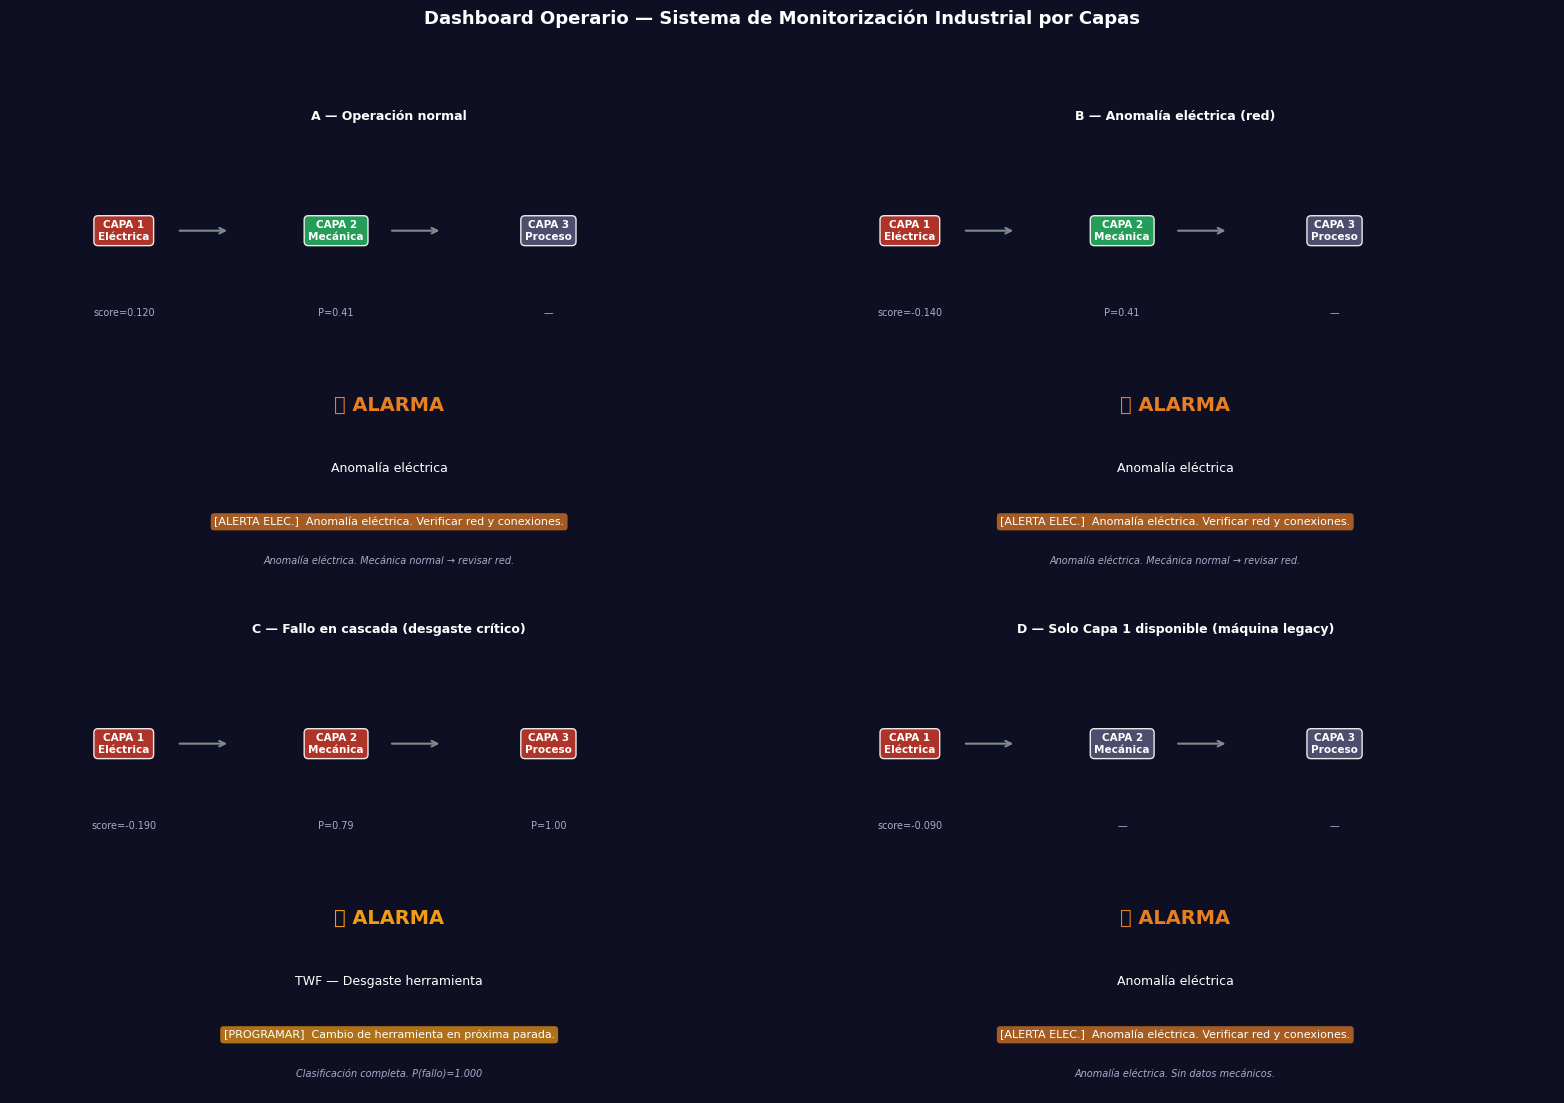

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

def draw_layer_indicator(ax_sub, active, triggered, label, score_text):
    """Dibuja un indicador de capa: gris=inactiva, verde=ok, rojo=alerta."""
    if not active:
        color = '#bdc3c7'; status = '○ SIN DATOS'
    elif triggered:
        color = '#e74c3c'; status = '● ALERTA'
    else:
        color = '#2ecc71'; status = '● NORMAL'
    ax_sub.text(0, 0, f'{label}\n{status}\n{score_text}',
                ha='center', va='center', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.5', facecolor=color,
                          alpha=0.85, edgecolor='white', linewidth=1.5),
                color='white', fontweight='bold')
    ax_sub.set_xlim(-1,1); ax_sub.set_ylim(-1,1); ax_sub.axis('off')

for idx, (name, r) in enumerate(results.items()):
    ax = axes[idx]
    ax.set_facecolor('#1a1a2e')
    fig.patch.set_facecolor('#0f0f23')

    # Título del escenario
    ax.text(0.5, 0.97, name, transform=ax.transAxes,
            ha='center', va='top', fontsize=9, color='white', fontweight='bold')

    # ── Indicadores de capa (3 mini-axes internos simulados con subregiones) ─
    gs = ax.get_subplotspec()
    # En lugar de sub-axes usamos bloques de texto posicionados
    layer_info = [
        (r.score_l1 is not None,
         r.score_l1 is not None and r.score_l1 < THRESHOLD_L1,
         'CAPA 1\nEléctrica',
         f'score={r.score_l1:.3f}' if r.score_l1 is not None else '—'),
        (r.prob_l2 is not None,
         r.prob_l2 is not None and r.prob_l2 >= THRESHOLD_L2,
         'CAPA 2\nMecánica',
         f'P={r.prob_l2:.2f}' if r.prob_l2 is not None else '—'),
        (r.prob_l3 is not None,
         r.prob_l3 is not None and r.prob_l3 >= threshold_ai4i,
         'CAPA 3\nProceso',
         f'P={r.prob_l3:.2f}' if r.prob_l3 is not None else '—'),
    ]

    for li, (active, triggered, label, score_text) in enumerate(layer_info):
        x = 0.15 + li * 0.28
        if not active:
            color = '#555577'
        elif triggered:
            color = '#c0392b'
        else:
            color = '#27ae60'
        ax.text(x, 0.72, label, transform=ax.transAxes,
                ha='center', va='center', fontsize=7.5, color='white',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor=color,
                          edgecolor='white', linewidth=1, alpha=0.9))
        ax.text(x, 0.55, score_text, transform=ax.transAxes,
                ha='center', va='center', fontsize=7, color='#aaaacc')
        if li < 2:  # flecha →
            ax.annotate('', xy=(x + 0.14, 0.72), xytext=(x + 0.07, 0.72),
                        xycoords='axes fraction', textcoords='axes fraction',
                        arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=1.5))

    # ── Resultado final ───────────────────────────────────────────────────────
    res_color = r.action_color
    alarm_text = '🔴 ALARMA' if r.alarm else '🟢 NORMAL'
    ax.text(0.5, 0.36, alarm_text, transform=ax.transAxes,
            ha='center', va='center', fontsize=14, color=res_color, fontweight='bold')

    ax.text(0.5, 0.23, r.fault_name, transform=ax.transAxes,
            ha='center', va='center', fontsize=9, color='white')

    ax.text(0.5, 0.12, f'[{r.action_label}]  {r.action_text}',
            transform=ax.transAxes, ha='center', va='center',
            fontsize=8, color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=res_color,
                      alpha=0.7, edgecolor='none'))

    ax.text(0.5, 0.03, r.details.get('msg',''), transform=ax.transAxes,
            ha='center', va='bottom', fontsize=7, color='#aaaacc', style='italic')

    ax.axis('off')

plt.suptitle('Dashboard Operario — Sistema de Monitorización Industrial por Capas',
             fontsize=13, color='white', y=1.01, fontweight='bold')
plt.tight_layout(pad=2.0)
plt.show()

## 7. Cobertura y coste por configuración de capas

En un escenario real, no todas las máquinas tienen los mismos sensores instalados.
Esta sección razona **qué capas hay disponibles según la máquina** — su **cobertura**
(qué % del parque puede usarla) y su **coste de instalación** — no un ranking de ahorro
en € entre capas.

> **Por qué no comparamos ahorro en €.** Las capas operan sobre dominios y datasets
> distintos y no detectan los mismos fallos sobre las mismas máquinas, así que sus
> recalls **no son combinables ni convertibles en € comparables**. Solo la **Capa 3**
> tiene recall de test (n=2000), única base defendible para una cifra económica. El
> recall=1.0 de "Capa 1+2" viene de un LOO con **n=18** (FN=0 → ahorro inflado) y el de
> "Solo Capa 1" es una estimación sin etiquetas. Por eso **solo se calcula € para la
> Capa 3**; las demás se presentan por cobertura y coste de instalación. (Coherente con
> la sección 4 del `06_04`.)


In [ ]:
# Parámetros económicos — pyme de criticidad media (coherente con 06_04)
COST_FN = 3_000   # € — fallo no detectado (parada imprevista)
COST_FP = 300      # € — alarma falsa (revisión innecesaria)

# Métricas REALES desde los bundles (la Capa 1 sigue siendo estimación declarada)
import yaml
with open(os.path.join(MODELS_DIR, 'model_config.yaml')) as f:
    _cfg = yaml.safe_load(f)
with open(os.path.join(MODELS_DIR, 'cnc_model.pkl'), 'rb') as f:
    _cnc = pickle.load(f)
_p3 = _cfg['performance']
_m2cnc = _cnc['metrics_loo']

# 'fiable' marca si el recall tiene muestra suficiente (test, n>=2000) para
# sostener una cifra económica. SOLO la Capa 3 la tiene. Por eso únicamente
# esa configuración recibe un ahorro en €; las demás se describen por su
# COBERTURA (% del parque que puede usarla) y su COSTE DE INSTALACIÓN por máquina.
configs = {
    'Solo Capa 1 (solo sensores eléctricos)': {
        'recall': 0.48, 'precision': 0.55,          # estimación declarada
        'coverage_pct': 100, 'cost_install': 500,
        'fuente': 'estimación declarada (sin etiquetas)', 'fiable': False,
    },
    'Capa 1 + 2 (eléctrico + CNC OPC-UA)': {
        'recall': _m2cnc['recall'], 'precision': _m2cnc['precision'],  # LOO cnc_model (n=18)
        'coverage_pct': 60, 'cost_install': 2000,
        'fuente': 'LOO cnc_model (n=18, IC amplio)', 'fiable': False,
    },
    'Capa 1 + 2 + 3 (sistema completo)': {
        'recall': _p3['recall'], 'precision': _p3['precision'],        # test AI4I
        'coverage_pct': 30, 'cost_install': 5000,
        'fuente': 'test AI4I (n=2000)', 'fiable': True,
    },
}

N_FAILURES_YEAR = 68        # fallos/año (del notebook 04_01)
N_PREDICTIONS   = 1000      # ciclos de predicción/año por máquina
N_MACHINES      = 5         # pyme: 5 máquinas → baseline ~1M€
baseline_cost   = N_FAILURES_YEAR * COST_FN * N_MACHINES   # coste sin ningún sistema

def annual_saving(cfg):
    """Ahorro anual frente al baseline. Solo es defendible si cfg['fiable']."""
    fn = int(N_FAILURES_YEAR * (1 - cfg['recall'])) * N_MACHINES
    fp = int(N_PREDICTIONS * (1 - cfg['precision']) * cfg['recall']) * N_MACHINES
    return baseline_cost - fn * COST_FN - fp * COST_FP

# ── Tabla: cobertura + coste + (ahorro SOLO para la config fiable) ───────────
print(f'{"Configuración":<42} {"Cobertura":>9} {"Instal./máq":>11} '
      f'{"Recall":>7} {"Ahorro/año":>14}  Fuente del recall')
print('─' * 122)
for cfg_name, cfg in configs.items():
    ahorro = f'€{annual_saving(cfg):,.0f}' if cfg['fiable'] else '—  (no en €)'
    print(f'{cfg_name:<42} {cfg["coverage_pct"]:>8}% €{cfg["cost_install"]:>9,} '
          f'{cfg["recall"]:>7.1%} {ahorro:>14}  {cfg["fuente"]}')

saving_full = annual_saving(configs['Capa 1 + 2 + 3 (sistema completo)'])
print(f'\nCoste baseline (sin sistema): €{baseline_cost:,.0f}/año')
print(f'Única cifra de ahorro defendible — Capa 1+2+3 (recall de test, n=2000): '
      f'€{saving_full:,.0f}/año en {N_MACHINES} máquinas.')
print('Las configuraciones "Solo Capa 1" y "Capa 1+2" NO reciben ahorro en €:')
print('  sus recalls (estimación / LOO n=18) no son convertibles en una cifra')
print('  económica comparable. Se justifican por cobertura y coste de instalación.')


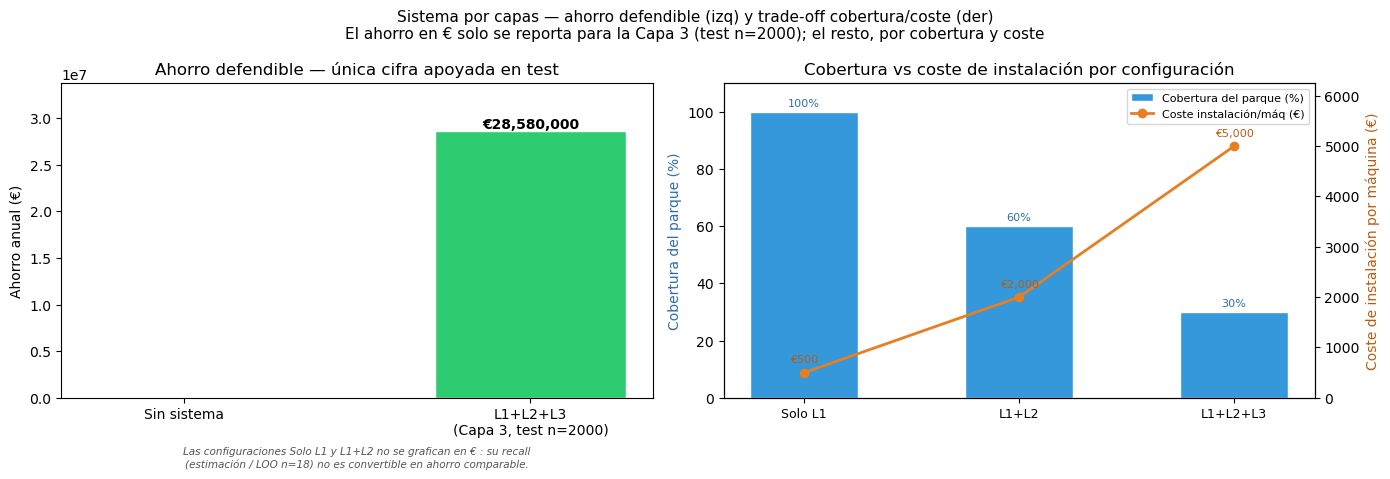

In [9]:
# Visualización — separamos las dos cosas que SÍ son comparables:
#   (izq) el único ahorro defendible en € (Capa 3, test n=2000) vs baseline
#   (der) cobertura vs coste de instalación por configuración (trade-off real)
# Ya NO se dibujan barras de ahorro para "Solo L1" / "L1+L2": sus recalls no son
# convertibles en € comparables, así que compararlas en ahorro inducía a error.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

short_map = {
    'Solo Capa 1 (solo sensores eléctricos)': 'Solo L1',
    'Capa 1 + 2 (eléctrico + CNC OPC-UA)':    'L1+L2',
    'Capa 1 + 2 + 3 (sistema completo)':      'L1+L2+L3',
}
short_names = [short_map[k] for k in configs]

# ── Panel izquierdo: ahorro defendible (solo Capa 3) ────────────────────────
ax0 = axes[0]
ax0.bar(['Sin sistema'], [0], color='#bdc3c7', edgecolor='white', width=0.55)
ax0.bar(['L1+L2+L3\n(Capa 3, test n=2000)'], [saving_full],
        color='#2ecc71', edgecolor='white', width=0.55)
ax0.set_ylabel('Ahorro anual (€)')
ax0.set_title('Ahorro defendible — única cifra apoyada en test')
ax0.text(1, saving_full, f'€{saving_full:,.0f}', ha='center', va='bottom',
         fontsize=10, fontweight='bold')
ax0.text(0.5, -0.22,
         'Las configuraciones Solo L1 y L1+L2 no se grafican en € : su recall\n'
         '(estimación / LOO n=18) no es convertible en ahorro comparable.',
         transform=ax0.transAxes, ha='center', fontsize=7.5, color='#555', style='italic')
ax0.margins(y=0.18)

# ── Panel derecho: cobertura vs coste de instalación (trade-off real) ────────
ax1 = axes[1]
coverage = [c['coverage_pct'] for c in configs.values()]
install  = [c['cost_install'] for c in configs.values()]
x = np.arange(len(short_names))

bars = ax1.bar(x, coverage, width=0.5, color='#3498db', edgecolor='white',
               label='Cobertura del parque (%)')
ax1.set_ylabel('Cobertura del parque (%)', color='#2c6fa6')
ax1.set_ylim(0, 110)
ax1.set_xticks(x); ax1.set_xticklabels(short_names, fontsize=9)
for xi, cov in zip(x, coverage):
    ax1.text(xi, cov + 2, f'{cov}%', ha='center', fontsize=8, color='#2c6fa6')

ax1b = ax1.twinx()
ax1b.plot(x, install, 'o-', color='#e67e22', lw=2, label='Coste instalación/máq (€)')
ax1b.set_ylabel('Coste de instalación por máquina (€)', color='#b85c12')
ax1b.set_ylim(0, max(install) * 1.25)
for xi, ci in zip(x, install):
    ax1b.text(xi, ci + max(install) * 0.04, f'€{ci:,}', ha='center',
              fontsize=8, color='#b85c12')

ax1.set_title('Cobertura vs coste de instalación por configuración')
h0, l0 = ax1.get_legend_handles_labels()
h1, l1 = ax1b.get_legend_handles_labels()
ax1.legend(h0 + h1, l0 + l1, loc='upper right', fontsize=8)

plt.suptitle('Sistema por capas — ahorro defendible (izq) y trade-off cobertura/coste (der)\n'
             'El ahorro en € solo se reporta para la Capa 3 (test n=2000); el resto, por cobertura y coste',
             fontsize=11)
plt.tight_layout()
plt.show()


## 8. Conclusiones y guía de despliegue

### Resultado del sistema

El pipeline de 3 capas reúne los tres datasets del proyecto en una arquitectura
que replica cómo funcionan los sistemas industriales reales:

| Capa | Dataset | Cuando actúa | Coste sensor | Qué aporta |
|---|---|---|---|---|
| 1 | SPARK | Siempre (1 min) | €500 (retrofit) | Detección temprana, cualquier máquina |
| 2 | KIT → **CNC** | Solo si L1 alerta | €0 extra (OPC-UA ya existe) | Confirma fallo mecánico; el modelo CNC se reentrena con datos reales |
| 3 | AI4I | Solo si L2 confirma | €5.000 (MES) | Clasifica tipo de fallo → acción concreta |

### Hoja de ruta de Capa 2: de prototipo a producción

1. **Prototipo** — modelo entrenado con KIT (33 experimentos, 500 Hz, sensores externos)
2. **Cold-start** — en el primer despliegue se sustituye por el modelo CNC (18 experimentos, señales internas del controlador)
3. **Reentrenamiento incremental** — cada semana se incorporan nuevos experimentos de la planta; el modelo mejora sin intervención manual

Este diseño elimina la necesidad de instalar sensores externos en cada máquina y
hace que el sistema sea auto-mejorante con el uso real.

### Principio clave: cobertura, coste y ahorro defendible

- **Cada capa cubre una parte distinta del parque a un coste distinto** (sección 7):
  la Capa 1 llega al 100% de máquinas por ~€500, pero su recall no está etiquetado;
  la Capa 3 solo aplica donde hay MES (~30% del parque) y cuesta ~€5.000, pero es
  la única con recall medido en test.
- **Solo la Capa 3 sostiene una cifra de ahorro en €** — recall de test (n=2000).
  Las configuraciones "Solo Capa 1" y "Capa 1+2" **no se expresan en € de ahorro**:
  sus recalls (estimación sin etiquetas / LOO con n=18) no son convertibles en una
  cifra económica comparable. Compararlas en € haría "ganar" a L1+L2 por un artefacto
  (recall=1.0 → FN=0), no por ser realmente mejor que el sistema completo.
- **El valor de las capas 1 y 2 es de cobertura y confirmación**, no de ahorro extra:
  detectan antes y en más máquinas, y filtran falsas alarmas antes de llegar a la
  Capa 3 — pero su aporte económico no se puede cuantificar con los datos disponibles.
- **El sistema degrada con elegancia** (*graceful degradation*): si un sensor falla,
  las otras capas siguen funcionando.

### Guía de despliegue en producción

```python
# Ejemplo de uso en producción (llamada cada 1 minuto por máquina)
signals = {
    'electrical': scada.get_spark_features(machine_id),   # siempre disponible
    'mechanical': cnc.get_cnc_features(machine_id),        # señales OPC-UA internas
    'process':    mes.get_process_params(machine_id),       # si tiene MES
}
result = pipeline.monitor(signals)

if result.alarm:
    cmms.create_work_order(
        machine    = machine_id,
        priority   = 'URGENT' if result.layers_activated == 3 else 'NORMAL',
        fault_type = result.fault_name,
        action     = result.action_text,
    )

# Reentrenamiento incremental del modelo CNC (Capa 2)
if new_labeled_experiment_available:
    cnc_model.partial_fit(new_experiment_features, new_experiment_label)
    cnc_model.save('models/cnc_model.pkl')
```

### Conexión con el proyecto
- **Notebook 04_01**: el modelo AI4I (Capa 3) alcanza F1=0.892 con umbral 0.9863
- **Notebook 04_04**: el Isolation Forest SPARK (Capa 1) detecta el 4.8% de lecturas anómalas
- **Notebook 04_03**: el Random Forest KIT valida el concepto de Capa 2 (baseline de referencia)
- **Notebook 05_01_7**: modelo CNC reentrenable — implementación de Capa 2 para producción